In [2]:
# Matplot Lib
import matplotlib
import matplotlib.pyplot as plt

# Plant CV
from plantcv import plantcv as pcv

# SVM Machine Learning
from skimage.feature import graycomatrix, graycoprops
from sklearn import svm

# Miscellenous
import os
import argparse
import numpy as py
from pathlib import Path

In [3]:
# Set-up Plant CV Global Parameters

class PlantCV_Configuration:
    def __init__(self):
        self.debug = "plot"
        self.writeimg = False
        self.result = ""
        self.outdir = "."

plant_cv_config = PlantCV_Configuration()
pcv.params.debug_outdir = plant_cv_config.outdir
pcv.params.debug = plant_cv_config.debug

In [4]:
# Get Path Of Data Set

current_directory = Path().cwd()
image_data_set_directory = current_directory / 'Plant_leave_diseases_dataset_without_augmentation'
image_data_set_directory.resolve()

poc_200_image_directory = image_data_set_directory / 'Apple___Apple_scab'
poc_200_image_directory.resolve()

PosixPath('/Users/darshan-non-work/Documents/Unisa/Honours-Research-Project/proof_of_concept/image_processing_poc/Plant_leave_diseases_dataset_without_augmentation/Apple___Apple_scab')

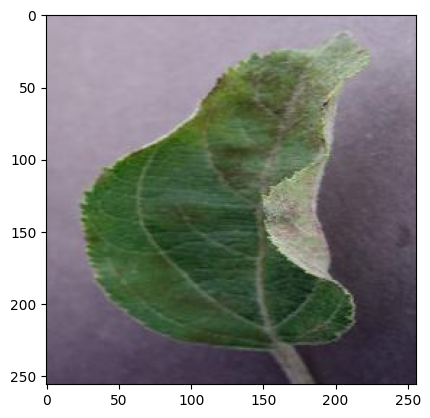

In [7]:
# Read the first 200 images
first_200_images = [str(image_path) for image_path in list(poc_200_image_directory.iterdir())[:200]]

img, path, filename = pcv.readimage(first_200_images[0], mode="rgb")

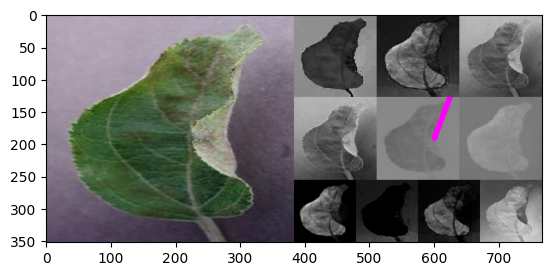

In [128]:
# Update params

pcv.params.text_size = 50
pcv.params.text_thickness = 15

colorspace = pcv.visualize.colorspaces(rgb_img=img)

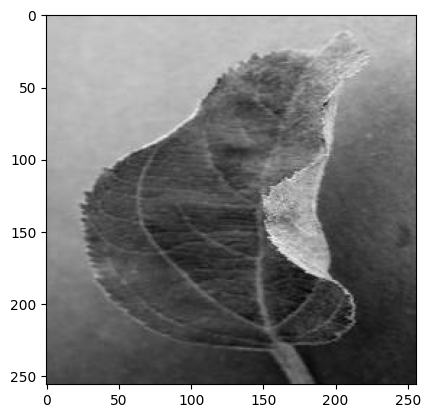

In [34]:
# RGB To Gray Scale Conversion
a = pcv.rgb2gray(rgb_img=img)

In [35]:
# Histogram of unequalized gray scale image
hist = pcv.visualize.histogram(a)

alt.Chart(...)

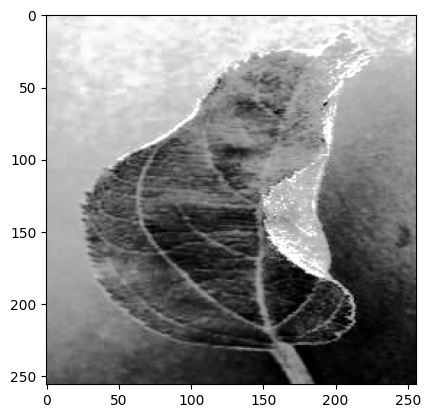

In [36]:
# Histogram Equalization
a_equalized = pcv.hist_equalization(a)

In [37]:
# Histogram Of Equalized Gray Scale Image
a_equalized_histogram = pcv.visualize.histogram(a_equalized)

alt.Chart(...)

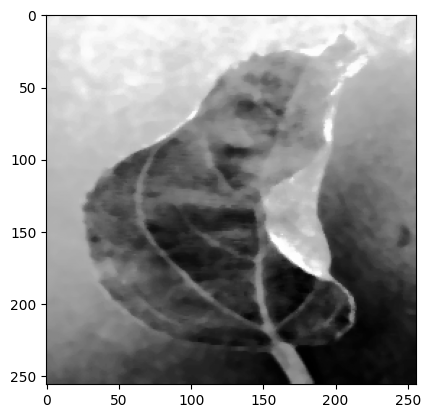

In [38]:
# Median Filtering
a_equalized_with_median_filtering = pcv.median_blur(a_equalized, 5)

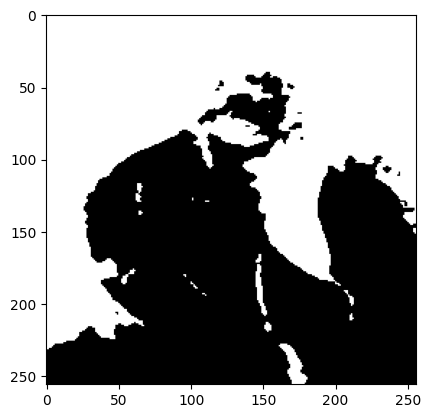

In [39]:
# Segmentation With Otsu Method
segmented_image_with_otsu = pcv.threshold.otsu(a_equalized_with_median_filtering, object_type="light")

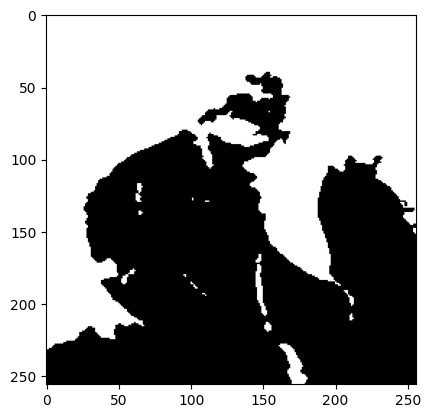

In [40]:
# Close Holes (Morphological Operation)
fill_image = pcv.fill_holes(bin_img=segmented_image_with_otsu)

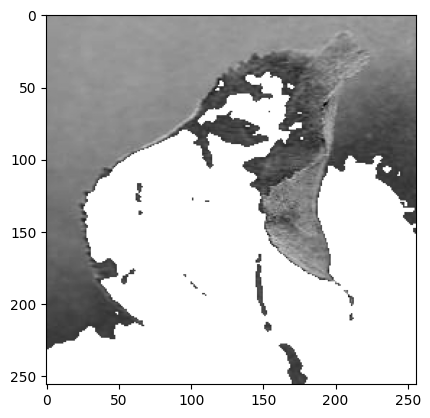

In [46]:
# Apply Mask From Otsu Method
background_removed_using_mask = pcv.apply_mask(img=a, mask=segmented_image_with_otsu, mask_color="white")

In [44]:
# Problems, I need to perform morphological operations to the mask so it is more accurate

In [48]:
# Obtain gray-level co-occurence matrix
glcm = graycomatrix(a_equalized_with_median_filtering, distances=[1], angles=[45], levels=256, symmetric=True, normed=True)

In [49]:
# Compute metrics from the GLCM
contrast = graycoprops(glcm, prop="contrast")
energy = graycoprops(glcm, prop="energy")
homogeneity = graycoprops(glcm, prop="homogeneity")
correlation = graycoprops(glcm, prop="correlation")
dissimilarity = graycoprops(glcm, prop="dissimilarity")
ASM = graycoprops(glcm, prop="ASM")
mean = graycoprops(glcm, prop="mean")
variance = graycoprops(glcm, prop="variance")
std = graycoprops(glcm, prop="std")
entropy = graycoprops(glcm, prop="entropy")

print(contrast)
print(energy)
print(homogeneity)
print(correlation)
print(dissimilarity)
print(ASM)
print(mean)
print(variance)
print(std)
print(entropy)

[[67.94089965]]
[[0.04636024]]
[[0.42068533]]
[[0.99357813]]
[[4.23352557]]
[[0.00214927]]
[[128.22459823]]
[[5289.80578785]]
[[72.73105106]]
[[6.90856725]]


In [56]:
# Define the feature vector
feature_vector = py.array([contrast[0][0], energy[0][0], homogeneity[0][0], correlation[0][0], dissimilarity[0][0], ASM[0][0], mean[0][0], variance[0][0], std[0][0], entropy[0][0]])
print(feature_vector)

[6.79408997e+01 4.63602411e-02 4.20685334e-01 9.93578129e-01
 4.23352557e+00 2.14927196e-03 1.28224598e+02 5.28980579e+03
 7.27310511e+01 6.90856725e+00]


In [122]:
# SVM

X = [feature_vector, [0,1,2,3,4,5,6,7,8,9]] # first index is the sample, second index is the feature vector
category_labels = [0,1] # the ith label is the label of the ith sample

classifier = svm.SVC()
classifier.fit(X, category_labels)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [123]:
classifier.predict(py.array([[0,1,2,3,4,5,6,7,8,9]]))

array([2])

In [110]:
# Next Step
# Need to preprocess the data i.e get all of the data into feature vectors

# split the training data set, train the SVM, and then predict various measures
# 1. Need to understand the support vector machine properly
# 2. What is kernal, degree etc
# 3. Need to know how to split the data_set, and how to cross-validate